In [1]:
# =============================================================================
# Cell 1: Imports and Spark Session (Using berdl_notebook_utils)
# =============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
from pyspark.sql import functions as F, Window
from pyspark.sql.types import DoubleType
import math

# Import the Spark session utility as in the original notebook
from berdl_notebook_utils.setup_spark_session import get_spark_session

# Get the pre-configured Spark session
spark = get_spark_session()

sns.set_theme(style="whitegrid", palette="muted")
print("Spark session acquired from berdl_notebook_utils.")

Spark session acquired from berdl_notebook_utils.


In [2]:
# =============================================================================
# Cell 2: Haversine UDF for Spatial Distance Calculation
# =============================================================================
def haversine(lat1, lon1, lat2, lon2):
    if None in (lat1, lon1, lat2, lon2):
        return None
    R = 6371.0
    lat1_rad = math.radians(lat1)
    lat2_rad = math.radians(lat2)
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

haversine_udf = F.udf(haversine, DoubleType())

In [3]:
# =============================================================================
# Cell: Configure Table Paths (Based on Original Notebook)
# =============================================================================
SOIL_DB = "arkinlab_microbeatlas"
KBASE_DB = "kbase_ke_pangenome"

SOIL_SAMPLE_TABLE = f"{SOIL_DB}.sample_metadata"
SOIL_ENRICHED_TABLE = f"{SOIL_DB}.enriched_metadata"
SOIL_GEE_TABLE = f"{SOIL_DB}.enriched_metadata_gee"
KBASE_COORDS_TABLE = f"{KBASE_DB}.alphaearth_embeddings_all_years"
KBASE_EGGNOG_TABLE = f"{KBASE_DB}.eggnog_mapper_annotations"
KBASE_GENE_TABLE = f"{KBASE_DB}.gene"

print("Table paths configured:")
print(f"  Soil sample: {SOIL_SAMPLE_TABLE}")
print(f"  Soil enriched: {SOIL_ENRICHED_TABLE}")
print(f"  Soil GEE: {SOIL_GEE_TABLE}")
print(f"  KBase coords: {KBASE_COORDS_TABLE}")
print(f"  KBase eggNOG: {KBASE_EGGNOG_TABLE}")
print(f"  KBase gene: {KBASE_GENE_TABLE}")

Table paths configured:
  Soil sample: arkinlab_microbeatlas.sample_metadata
  Soil enriched: arkinlab_microbeatlas.enriched_metadata
  Soil GEE: arkinlab_microbeatlas.enriched_metadata_gee
  KBase coords: kbase_ke_pangenome.alphaearth_embeddings_all_years
  KBase eggNOG: kbase_ke_pangenome.eggnog_mapper_annotations
  KBase gene: kbase_ke_pangenome.gene


In [4]:
# =============================================================================
# Cell: Load Soil Metal Data
# =============================================================================
try:
    df_sample = spark.table(SOIL_SAMPLE_TABLE)
    print(f"✓ Loaded {SOIL_SAMPLE_TABLE}")
except Exception as e:
    print(f"✗ Failed to load {SOIL_SAMPLE_TABLE}: {e}")
    raise

try:
    df_enriched = spark.table(SOIL_ENRICHED_TABLE)
    print(f"✓ Loaded {SOIL_ENRICHED_TABLE}")
except Exception as e:
    print(f"✗ Failed to load {SOIL_ENRICHED_TABLE}: {e}")
    raise

try:
    df_gee = spark.table(SOIL_GEE_TABLE)
    print(f"✓ Loaded {SOIL_GEE_TABLE}")
except Exception as e:
    print(f"✗ Failed to load {SOIL_GEE_TABLE}: {e}")
    raise

# Deduplicate
df_enriched = df_enriched.withColumn("rn", F.row_number().over(Window.partitionBy("accession_id").orderBy("accession_id"))).filter(F.col("rn") == 1).drop("rn")
df_gee = df_gee.withColumn("rn", F.row_number().over(Window.partitionBy("SRS_Join_Key").orderBy("SRS_Join_Key"))).filter(F.col("rn") == 1).drop("rn")

# Join
df_soil_raw = (
    df_sample.alias("s")
    .join(df_enriched.alias("e"), F.col("s.sample_id") == F.col("e.accession_id"), "inner")
    .join(df_gee.alias("g"), F.col("s.SRS_Join_Key") == F.col("g.SRS_Join_Key"), "inner")
)

# Filter soil samples
df_soil_raw = df_soil_raw.filter(
    (F.col("s.SRS_Join_Key").isNotNull()) &
    (F.col("s.n_genes_by_counts").isNotNull()) &
    (F.col("s.Env_Level_1") == "soil")
).filter(
    F.col("g.LatitudeParsed").isNotNull() & F.col("g.LongitudeParsed").isNotNull()
)

# Metal columns
metal_columns = [
    "e.GeoROC_Rocks_georoc_Co_ppm", "e.GeoROC_Rocks_georoc_Cr_ppm",
    "e.GeoROC_Rocks_georoc_Cu_ppm", "e.GeoROC_Rocks_georoc_Ni_ppm",
    "e.GeoROC_Rocks_georoc_Zn_ppm", "e.GeoROC_Rocks_georoc_Pb_ppm",
    "e.GeoROC_Rocks_georoc_As_ppm", "e.GeoROC_Rocks_georoc_Cd_ppm",
    "e.GeoROC_Rocks_georoc_Hg_ppm"
]

df_soil_metal = df_soil_raw.select(
    F.col("s.sample_id"),
    F.col("g.LatitudeParsed").alias("lat"),
    F.col("g.LongitudeParsed").alias("lon"),
    F.col("g.ph").alias("ph"),
    *[F.col(c).cast("double").alias(c.split(".")[-1]) for c in metal_columns]
).cache()

print(f"Total soil samples with metal data: {df_soil_metal.count()}")
df_soil_metal.show(5, truncate=False)

✓ Loaded arkinlab_microbeatlas.sample_metadata
✓ Loaded arkinlab_microbeatlas.enriched_metadata
✓ Loaded arkinlab_microbeatlas.enriched_metadata_gee
Total soil samples with metal data: 51748
+----------------------+----------------+-----------------+-------+--------------------------+--------------------------+--------------------------+--------------------------+--------------------------+--------------------------+--------------------------+--------------------------+--------------------------+
|sample_id             |lat             |lon              |ph     |GeoROC_Rocks_georoc_Co_ppm|GeoROC_Rocks_georoc_Cr_ppm|GeoROC_Rocks_georoc_Cu_ppm|GeoROC_Rocks_georoc_Ni_ppm|GeoROC_Rocks_georoc_Zn_ppm|GeoROC_Rocks_georoc_Pb_ppm|GeoROC_Rocks_georoc_As_ppm|GeoROC_Rocks_georoc_Cd_ppm|GeoROC_Rocks_georoc_Hg_ppm|
+----------------------+----------------+-----------------+-------+--------------------------+--------------------------+--------------------------+--------------------------+------------

In [5]:
# =============================================================================
# Cell: Load KBase Genome Data with COG Annotations
# =============================================================================
# Coordinates
try:
    df_kbase_coords = spark.table(KBASE_COORDS_TABLE) \
        .select(
            F.col("genome_id"),
            F.expr("TRY_CAST(cleaned_lat AS DOUBLE)").alias("lat"),
            F.expr("TRY_CAST(cleaned_lon AS DOUBLE)").alias("lon")
        ).filter(F.col("lat").isNotNull())
    print(f"✓ Loaded {KBASE_COORDS_TABLE}")
except Exception as e:
    print(f"✗ Failed to load {KBASE_COORDS_TABLE}: {e}")
    raise

# eggNOG
try:
    df_eggnog = spark.table(KBASE_EGGNOG_TABLE) \
        .select(
            F.col("query_name").alias("gene_id"),
            F.col("COG_category")
        )
    print(f"✓ Loaded {KBASE_EGGNOG_TABLE}")
except Exception as e:
    print(f"✗ Failed to load {KBASE_EGGNOG_TABLE}: {e}")
    raise

# Gene map
try:
    df_gene_map = spark.table(KBASE_GENE_TABLE) \
        .select("gene_id", "genome_id")
    print(f"✓ Loaded {KBASE_GENE_TABLE}")
except Exception as e:
    print(f"✗ Failed to load {KBASE_GENE_TABLE}: {e}")
    raise

# Aggregate COG per genome
df_genome_cog = df_gene_map.join(df_eggnog, "gene_id", "inner") \
    .groupBy("genome_id", "COG_category").count() \
    .groupBy("genome_id").pivot("COG_category").sum("count").fillna(0)

# Join with coordinates
df_kbase_cog = df_kbase_coords.join(df_genome_cog, "genome_id", "left").fillna(0)

print(f"KBase genomes with coordinates: {df_kbase_cog.count()}")
df_kbase_cog.show(5, truncate=False)

✓ Loaded kbase_ke_pangenome.alphaearth_embeddings_all_years
✓ Loaded kbase_ke_pangenome.eggnog_mapper_annotations
✓ Loaded kbase_ke_pangenome.gene
KBase genomes with coordinates: 83286
+------------------+-----------+----------+---+---+---+---+---+---+----+---+---+---+---+---+---+---+---+---+---+---+---+-----+---+---+---+---+---+---+---+---+---+---+---+---+----+---+----+---+---+---+---+---+---+---+---+---+-----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+----+---+---+---+---+---+---+---+---+------+----+----+---+---+---+---+---+---+----+---+---+---+---+---+---+---+---+----+-----+----+---+----+---+---+---+---+-----+---+-----+----+----+---+----+---+---+---+---+---+---+---+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+----+---+---+---+---+---+----+----+-----+------+-----+----+-----+---+----+---+---+---+----+----+---+---+---+---+---+---+---+----+---+---+---+---+---+---+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---

In [6]:
# =============================================================================
# Cell: Spatial Join with Binning and Distance Filter
# =============================================================================
RADIUS_KM = 10.0

spark_soil_binned = df_soil_metal.withColumn("lat_bin", F.round("lat", 1)) \
                                 .withColumn("lon_bin", F.round("lon", 1))

spark_kbase_binned = df_kbase_cog.withColumn("lat_bin", F.round("lat", 1)) \
                                 .withColumn("lon_bin", F.round("lon", 1))

joined = spark_soil_binned.alias("soil").join(
    spark_kbase_binned.alias("kb"),
    on=["lat_bin", "lon_bin"],
    how="inner"
)

nearby = joined.withColumn(
    "distance_km",
    haversine_udf(
        F.col("soil.lat"), F.col("soil.lon"),
        F.col("kb.lat"), F.col("kb.lon")
    )
).filter(F.col("distance_km") <= RADIUS_KM).cache()

total_soil = df_soil_metal.count()
distinct_soil = nearby.select("soil.sample_id").distinct().count()
print(f"Soil samples with ≥1 genome within {RADIUS_KM} km: {distinct_soil} (out of {total_soil})")

Soil samples with ≥1 genome within 10.0 km: 7566 (out of 51748)


In [7]:
# =============================================================================
# Cell: Aggregate and Normalize COG Counts per Soil Sample
# =============================================================================
cog_columns = [c for c in df_genome_cog.columns if c != "genome_id"]
print(f"Number of COG categories: {len(cog_columns)}")

df_genome_count = nearby.groupBy("soil.sample_id").agg(
    F.count("kb.genome_id").alias("num_nearby_genomes")
)

agg_exprs = [F.sum(F.col(f"kb.{c}")).alias(f"sum_{c}") for c in cog_columns]
df_cog_sum = nearby.groupBy("soil.sample_id").agg(*agg_exprs)

norm_exprs = [(F.col(f"sum_{c}") / F.col("num_nearby_genomes")).alias(f"avg_{c}") for c in cog_columns]
df_cog_norm = df_cog_sum.join(df_genome_count, "sample_id").select("sample_id", "num_nearby_genomes", *norm_exprs)

df_metal_cog = df_soil_metal.join(df_cog_norm, "sample_id", "left").fillna(0)

# Downsample for performance
pdf_metal_cog = df_metal_cog.sample(fraction=0.3, seed=42).toPandas()
print(f"Final dataset shape (downsampled): {pdf_metal_cog.shape}")
pdf_metal_cog.head()

Number of COG categories: 435
Final dataset shape (downsampled): (15618, 449)


,sample_id,lat,lon,ph,GeoROC_Rocks_georoc_Co_ppm,GeoROC_Rocks_georoc_Cr_ppm,GeoROC_Rocks_georoc_Cu_ppm,GeoROC_Rocks_georoc_Ni_ppm,GeoROC_Rocks_georoc_Zn_ppm,GeoROC_Rocks_georoc_Pb_ppm,...,avg_TZ,avg_U,avg_UW,avg_UY,avg_UZ,avg_V,avg_VW,avg_W,avg_Y,avg_Z
0,SRR10089070.SRS5364427,27.142328,-81.35767,Unknown,65.4,0.0,316.6,187.1,1131.8,0.0,...,0.0,0.00,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0
1,SRR10174653.SRS5428797,44.120000,-89.53000,Unknown,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0
2,SRR10301170.SRS5534644,51.139528,10.35859,Unknown,61.2,0.0,0.0,0.0,0.0,0.0,...,0.0,18.75,0.0,0.0,0.0,24.125,0.0,0.0,0.0,0.0
3,SRR10312514.SRS5544707,72.392760,-77.52348,Unknown,40.0,337.0,160.0,77.0,97.0,0.0,...,0.0,0.00,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0
4,SRR10454301.SRS5656435,46.729800,-117.18170,Unknown,0.0,271.0,87.0,117.0,83.0,5.0,...,0.0,0.00,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0


In [8]:
# =============================================================================
# Cell: Spearman Correlation with FDR Correction
# =============================================================================
METAL_COL = 'GeoROC_Rocks_georoc_Cu_ppm'
cog_avg_cols = [f"avg_{c}" for c in cog_columns]

corr_results = []
for cog_col in cog_avg_cols:
    valid = pdf_metal_cog[[METAL_COL, cog_col]].dropna()
    if len(valid) < 5 or valid[cog_col].nunique() <= 1:
        continue
    corr, p = spearmanr(valid[METAL_COL], valid[cog_col])
    corr_results.append({
        'COG': cog_col.replace('avg_', ''),
        'correlation': corr,
        'p_value': p
    })

df_corr = pd.DataFrame(corr_results)
if len(df_corr) > 0:
    _, df_corr['p_adj_fdr'], _, _ = multipletests(df_corr['p_value'], method='fdr_bh')
    df_corr = df_corr.sort_values('p_adj_fdr')

sig_corr = df_corr[df_corr['p_adj_fdr'] < 0.05]
print(f"Significant COG categories (FDR < 0.05): {len(sig_corr)}")
sig_corr.head(10)

Significant COG categories (FDR < 0.05): 116


,COG,correlation,p_value,p_adj_fdr
9,BQ,-0.071164,5.384128e-19,1.243734e-16
91,FQ,-0.069135,5.167134e-18,5.968040e-16
86,FK,-0.060270,4.760140e-14,3.665308e-12
17,CF,-0.059373,1.120517e-13,6.470985e-12
11,CE,-0.058725,2.061501e-13,9.524136e-12
147,IU,-0.058427,2.724244e-13,1.048834e-11
221,QU,-0.057955,4.220553e-13,1.392782e-11
228,UW,-0.055439,4.117153e-12,1.188828e-10
48,DNZ,0.053299,2.645197e-11,6.789338e-10
199,NOU,-0.053036,3.308318e-11,7.642214e-10


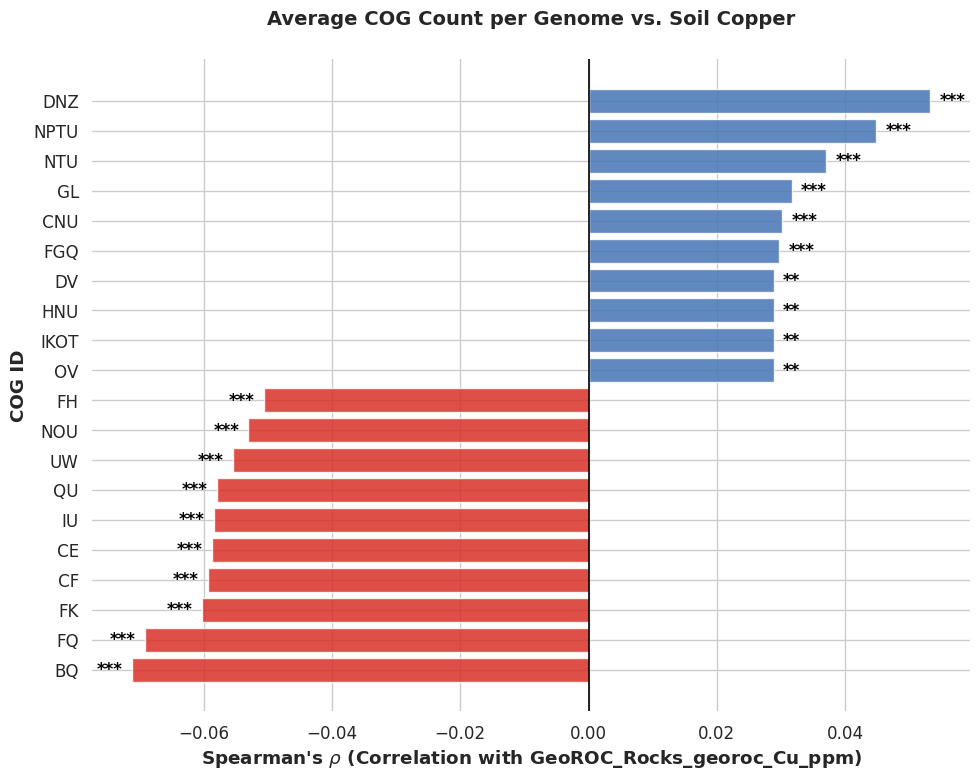

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Professional Styling
sns.set_theme(style="whitegrid", font_scale=1.1)

if len(sig_corr) > 0:
    # 2. Selection & Sorting for a "Waterfall" effect
    top_pos = sig_corr[sig_corr['correlation'] > 0].nlargest(10, 'correlation')
    top_neg = sig_corr[sig_corr['correlation'] < 0].nsmallest(10, 'correlation')
    
    # Sort from most negative to most positive
    plot_df = pd.concat([top_pos, top_neg]).sort_values('correlation', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 3. Use the professional diverging palette
    colors = ['#d73027' if r < 0 else '#4575b4' for r in plot_df['correlation']]
    bars = ax.barh(plot_df['COG'], plot_df['correlation'], 
                   color=colors, edgecolor='white', alpha=0.85)

    # 4. Refined Labels & Titles
    # Using LaTeX for the rho symbol makes it publication-ready
    ax.set_xlabel(f"Spearman's $\\rho$ (Correlation with {METAL_COL})", fontweight='bold')
    ax.set_ylabel("COG ID", fontweight='bold')
    ax.set_title('Average COG Count per Genome vs. Soil Copper', 
                 pad=25, fontsize=14, fontweight='bold')

    # 5. Visual Cleanup
    ax.axvline(x=0, color='black', linewidth=1.2, linestyle='-')
    sns.despine(left=True, bottom=True)

    # 6. Smart Significance Stars
    # We calculate an offset so stars don't touch the bars
    max_val = plot_df['correlation'].abs().max()
    offset = max_val * 0.02
    
    for bar, p_adj in zip(bars, plot_df['p_adj_fdr']):
        width = bar.get_width()
        
        # Determine significance level
        symbol = ''
        if p_adj < 0.001: symbol = '***'
        elif p_adj < 0.01: symbol = '**'
        elif p_adj < 0.05: symbol = '*'
        
        if symbol:
            # Adjust horizontal alignment (ha) and position based on bar direction
            if width < 0:
                x_pos = width - offset
                ha = 'right'
            else:
                x_pos = width + offset
                ha = 'left'
                
            ax.text(x_pos, bar.get_y() + bar.get_height()/2, symbol, 
                    va='center', ha=ha, color='black', 
                    fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No significant correlations after FDR correction.")

In [10]:
# =============================================================================
# Cell: Load GTDB Taxonomy Table
# =============================================================================
# Load GTDB taxonomy for KBase genomes
GTDB_TABLE = f"{KBASE_DB}.gtdb_taxonomy_r214v1"

try:
    df_gtdb = spark.table(GTDB_TABLE) \
        .select("genome_id", "domain", "phylum", "class", "order", "family", "genus", "species")
    print(f"✓ Loaded {GTDB_TABLE}")
except Exception as e:
    print(f"✗ Failed to load {GTDB_TABLE}: {e}")
    raise

print(f"KBase genomes with GTDB taxonomy: {df_gtdb.count()}")
df_gtdb.show(5, truncate=False)

✓ Loaded kbase_ke_pangenome.gtdb_taxonomy_r214v1
KBase genomes with GTDB taxonomy: 293059
+------------------+-----------+-----------------+----------------------+-------------------+---------------------+--------------+-------------------------+
|genome_id         |domain     |phylum           |class                 |order              |family               |genus         |species                  |
+------------------+-----------+-----------------+----------------------+-------------------+---------------------+--------------+-------------------------+
|RS_GCF_020034805.1|d__Bacteria|p__Pseudomonadota|c__Gammaproteobacteria|o__Enterobacterales|f__Enterobacteriaceae|g__Escherichia|s__Escherichia fergusonii|
|RS_GCF_013812875.1|d__Bacteria|p__Pseudomonadota|c__Gammaproteobacteria|o__Enterobacterales|f__Enterobacteriaceae|g__Escherichia|s__Escherichia fergusonii|
|RS_GCF_019839545.1|d__Bacteria|p__Pseudomonadota|c__Gammaproteobacteria|o__Enterobacterales|f__Enterobacteriaceae|g__Escheri

In [11]:
# =============================================================================
# Cell: Load OTU Data and Aggregate to Order Level
# =============================================================================
# Load OTU counts (long format)
OTU_TABLE = f"{SOIL_DB}.otu_counts_long"
OTU_METADATA_TABLE = f"{SOIL_DB}.otu_metadata"

try:
    df_otu = spark.table(OTU_TABLE)
    print(f"✓ Loaded {OTU_TABLE}")
except Exception as e:
    print(f"✗ Failed to load {OTU_TABLE}: {e}")
    raise

try:
    df_otu_tax = spark.table(OTU_METADATA_TABLE)
    print(f"✓ Loaded {OTU_METADATA_TABLE}")
except Exception as e:
    print(f"✗ Failed to load {OTU_METADATA_TABLE}: {e}")
    raise

# Parse taxonomy string into ranks
ranks = ["Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"]
df_otu_tax = df_otu_tax.withColumn("tax_array", F.split(F.col("Tax"), ";"))
for i, rank in enumerate(ranks):
    df_otu_tax = df_otu_tax.withColumn(rank, F.try_element_at(F.col("tax_array"), F.lit(i+1)))
df_otu_tax = df_otu_tax.drop("tax_array")

# Join OTU counts with taxonomy
df_otu_full = df_otu.join(df_otu_tax.select("otu_id", "Order"), "otu_id", "inner")

# Aggregate abundance by Order per sample
df_order_abund = df_otu_full.groupBy("sample_id", "Order").agg(F.sum("count").alias("abundance"))

# Calculate relative abundance per sample
sample_totals = df_order_abund.groupBy("sample_id").agg(F.sum("abundance").alias("total"))
df_order_rel = df_order_abund.join(sample_totals, "sample_id") \
    .withColumn("rel_abundance", F.col("abundance") / F.col("total")) \
    .select("sample_id", "Order", "rel_abundance")

print(f"Order-level relative abundance data: {df_order_rel.count()} rows")
df_order_rel.show(5, truncate=False)

✓ Loaded arkinlab_microbeatlas.otu_counts_long
✓ Loaded arkinlab_microbeatlas.otu_metadata
Order-level relative abundance data: 27121193 rows
+-------------------+-----------------+---------------------+
|sample_id          |Order            |rel_abundance        |
+-------------------+-----------------+---------------------+
|DRR000802.DRS000505|Acidothermales   |3.221303554171588E-4 |
|DRR000802.DRS000505|Rhodobacterales  |5.368839256952647E-4 |
|DRR000802.DRS000505|Nitrosomonadales |0.0017180285622248469|
|DRR000802.DRS000505|Pseudonocardiales|1.0737678513905293E-4|
|DRR000802.DRS000505|Acidimicrobiales |0.0024696660581982176|
+-------------------+-----------------+---------------------+
only showing top 5 rows


In [12]:
# =============================================================================
# Cell: Clean Taxonomic Names for Joining
# =============================================================================
def clean_taxon(col):
    """Remove prefixes like 'o__' and convert to lowercase."""
    return F.lower(F.regexp_replace(F.col(col), "^[a-z]__", ""))

# Clean Order names in both datasets
df_order_rel_clean = df_order_rel.withColumn("order_clean", clean_taxon("Order"))
df_gtdb_clean = df_gtdb.withColumn("order_clean", clean_taxon("order"))

# Join COG counts with GTDB order
df_genome_cog_order = df_genome_cog.join(df_gtdb_clean, "genome_id", "inner")

print(f"Genomes with Order-level taxonomy and COG data: {df_genome_cog_order.count()}")
df_genome_cog_order.show(5, truncate=False)

Genomes with Order-level taxonomy and COG data: 271760
+------------------+---+---+---+---+---+---+----+---+---+---+---+---+---+---+---+---+---+---+---+-----+---+---+---+---+---+---+---+---+---+---+---+---+----+---+----+---+---+---+---+---+---+---+---+---+-----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+----+---+---+---+---+---+---+---+---+------+----+----+---+---+---+---+---+---+----+---+---+---+---+---+---+---+---+----+-----+----+---+----+---+---+---+---+-----+---+-----+----+----+---+----+---+---+---+---+---+---+---+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+----+---+---+---+---+---+----+----+-----+------+-----+----+-----+---+----+---+---+---+----+----+---+---+---+---+---+---+---+----+---+---+---+---+---+---+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+----+---+---+---+---+---+---+---+---+---+---+-----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+-

In [13]:
# =============================================================================
# Cell: Perform Taxonomic Join (Order Level)
# =============================================================================
# Join soil Order relative abundance with genome COG counts on cleaned Order
joined_tax = df_order_rel_clean.alias("soil").join(
    df_genome_cog_order.alias("kb"),
    on="order_clean",
    how="inner"
)

print(f"Join result rows: {joined_tax.count()}")
joined_tax.show(5, truncate=False)

Join result rows: 37071356233
+--------------+-------------------+--------------+---------------------+------------------+---+---+---+---+---+---+----+---+---+---+---+---+---+---+---+---+---+---+---+-----+---+---+---+---+---+---+---+---+---+---+---+---+----+---+----+---+---+---+---+---+---+---+---+---+-----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+----+---+---+---+---+---+---+---+---+------+----+----+---+---+---+---+---+---+----+---+---+---+---+---+---+---+---+----+-----+----+---+----+---+---+---+---+-----+---+-----+----+----+---+----+---+---+---+---+---+---+---+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+----+---+---+---+---+---+----+----+-----+------+-----+----+-----+---+----+---+---+---+----+----+---+---+---+---+---+---+---+----+---+---+---+---+---+---+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+----+---+---+---+---+---+---+---+---+---+---+-----+---+---+---+---+---+---+---+--

In [14]:
# Assuming joined_tax has columns: sample_id, genome_id, rel_abundance
df_genome_abundance = joined_tax.groupBy("sample_id", "genome_id") \
    .agg(F.sum("rel_abundance").alias("total_abundance"))
# This reduces rows to at most (samples × genomes) instead of per-ASV rows.

In [15]:
from pyspark.sql.functions import broadcast

# df_genome_cog has columns: genome_id, [cog_columns...]
# Broadcast works well if the COG matrix fits in memory (271k genomes * ~400 cols * 8 bytes ≈ 870 MB - may be borderline, but often OK with sufficient executor memory)
df_weighted = df_genome_abundance.join(
    broadcast(df_genome_cog),
    "genome_id",
    "inner"
)

In [16]:
cog_columns = [c for c in df_genome_cog.columns if c != "genome_id"]

# Build aggregation expressions
weighted_exprs = [F.sum(F.col("total_abundance") * F.col(c)).alias(f"weighted_{c}") for c in cog_columns]

df_community_cog = df_weighted.groupBy("sample_id").agg(*weighted_exprs)

In [17]:
# Join with soil metal data
df_metal_community = df_soil_metal.join(df_community_cog, "sample_id", "left").fillna(0)

In [21]:
spark.conf.set("spark.sql.ansi.enabled", "false")

In [26]:
# Disable ANSI to avoid divide-by-zero errors
spark.conf.set("spark.sql.ansi.enabled", "false")

# Copper column name (verify this matches your data)
copper_col = "GeoROC_Rocks_georoc_Cu_ppm"

# Get all weighted COG columns
cog_cols = [c for c in df_metal_community.columns if c.startswith("weighted_")]

# Build SQL parts with backtick-quoted column names
select_parts = []
for c in cog_cols:
    select_parts.append(f"corr(`{copper_col}`, `{c}`) AS `{c}`")

query = f"SELECT {', '.join(select_parts)} FROM comm"
df_metal_community.createOrReplaceTempView("comm")

# Execute (one Spark job)
df_all_corrs = spark.sql(query)

# Convert to Pandas (1 row × N columns, tiny)
pdf_corrs = df_all_corrs.toPandas().T.reset_index()
pdf_corrs.columns = ["COG_category", "correlation_with_copper"]
pdf_corrs = pdf_corrs.sort_values("correlation_with_copper", ascending=False)

# Show results
pdf_corrs.head(20)

,COG_category,correlation_with_copper
194,weighted_FI,0.048336
189,weighted_FGP,0.027421
205,weighted_FPT,0.025201
92,weighted_DKLTZ,0.024967
132,weighted_EFT,0.018033
343,weighted_LMNU,0.018033
333,weighted_KPT,0.016920
148,weighted_EGPT,0.016057
59,weighted_CNT,0.011056
320,weighted_KLTU,0.009082


In [32]:
num_samples = df_metal_community.count()
num_cols = len(df_metal_community.columns)
print(f"Samples: {num_samples}, Columns: {num_cols}")
print(f"Estimated memory in Pandas: {num_samples * num_cols * 8 / 1e6:.2f} MB")

Samples: 51748, Columns: 448
Estimated memory in Pandas: 185.46 MB


In [33]:
driver_memory_gb = spark.conf.get("spark.driver.memory", "1g")
print(f"Driver memory configured: {driver_memory_gb}")

Driver memory configured: 8g


In [34]:
from tqdm import tqdm
import pandas as pd

print("Collecting sample-level DataFrame to Pandas...")
# Convert Spark DataFrame to Pandas (this triggers one final Spark job)
pdf_community = df_metal_community.toPandas()
print(f"Collected: {pdf_community.shape}")

Collected: (51748, 448)


In [35]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import pandas as pd

METAL_COL = 'GeoROC_Rocks_georoc_Cu_ppm'
weighted_cols = [c for c in pdf_community.columns if c.startswith('weighted_')]

results = []
for col in tqdm(weighted_cols, desc="Computing Spearman correlations"):
    valid = pdf_community[[METAL_COL, col]].dropna()
    if len(valid) < 5 or valid[col].nunique() <= 1:
        continue
    r, p = spearmanr(valid[METAL_COL], valid[col])
    results.append({
        'COG': col.replace('weighted_', ''),
        'spearman_r': r,
        'p_value': p
    })

df_corr = pd.DataFrame(results)
if len(df_corr) > 0:
    _, p_adj_fdr, _, _ = multipletests(df_corr['p_value'], method='fdr_bh')
    df_corr['p_adj_fdr'] = p_adj_fdr
    df_corr = df_corr.sort_values('p_adj_fdr')

sig = df_corr[df_corr['p_adj_fdr'] < 0.05]
print(f"\nSignificant COG categories (FDR < 0.05): {len(sig)} out of {len(df_corr)}")
if len(sig) > 0:
    display(sig[['COG', 'spearman_r', 'p_adj_fdr']].head(10))

Computing Spearman correlations: 100%|██████████| 435/435 [00:03<00:00, 124.15it/s]


Significant COG categories (FDR < 0.05): 225 out of 391


,COG,spearman_r,p_adj_fdr
193,GIQ,0.072929,2.240022e-59
77,DI,0.069999,3.127476e-55
140,EIQ,0.069999,3.127476e-55
157,EPQ,0.069999,3.127476e-55
36,CFO,0.064081,2.471842e-46
107,DUW,0.061743,4.448732e-43
324,MNUV,0.060836,6.940851e-42
208,GMU,0.059417,5.235048e-40
91,DMQZ,-0.058097,2.665806e-38
214,GNU,0.057652,9.220253e-38


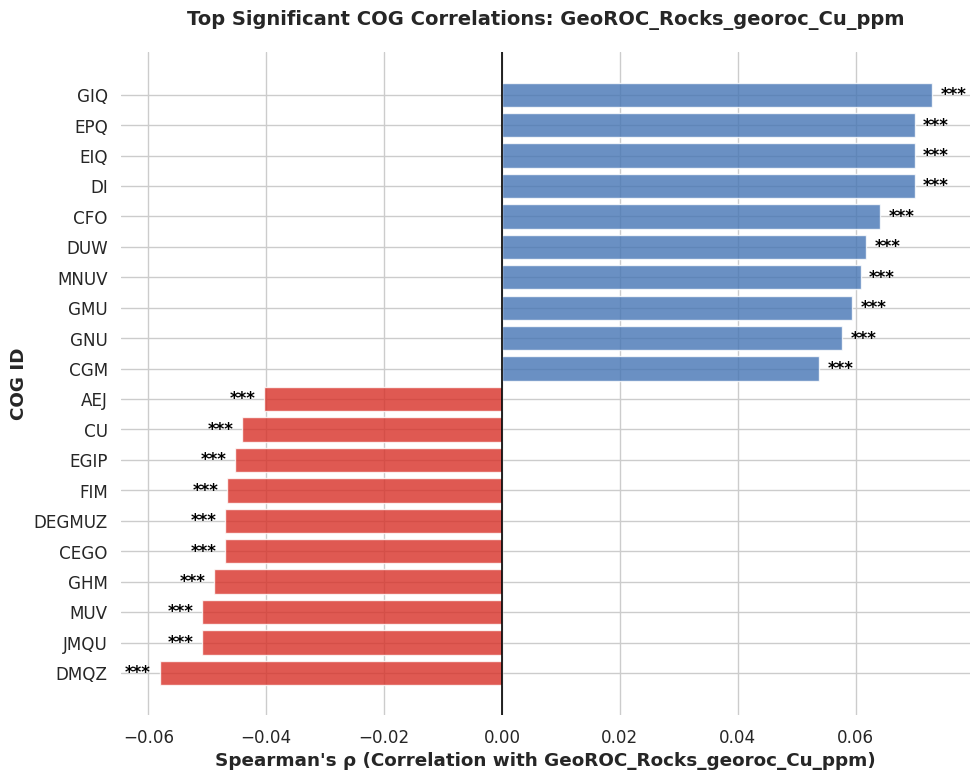

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set a professional style
sns.set_theme(style="whitegrid", font_scale=1.1)

if len(sig) > 0:
    # 1. Selection & Sorting
    top_pos = sig[sig['spearman_r'] > 0].nlargest(10, 'spearman_r')
    top_neg = sig[sig['spearman_r'] < 0].nsmallest(10, 'spearman_r')
    
    # Concatenate and sort by value for a clean "waterfall" effect
    plot_df = pd.concat([top_pos, top_neg]).sort_values('spearman_r', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 2. Use a professional diverging palette
    colors = ['#d73027' if r < 0 else '#4575b4' for r in plot_df['spearman_r']]
    bars = ax.barh(plot_df['COG'], plot_df['spearman_r'], color=colors, edgecolor='white', alpha=0.8)

    # 3. Refined Labels & Title
    ax.set_xlabel(f"Spearman's ρ (Correlation with {METAL_COL})", fontweight='bold')
    ax.set_ylabel("COG ID", fontweight='bold')
    ax.set_title(f'Top Significant COG Correlations: {METAL_COL}', pad=20, fontsize=14, fontweight='bold')

    # 4. Zero line and axis cleanup
    ax.axvline(x=0, color='black', linewidth=1.2, linestyle='-')
    sns.despine(left=True, bottom=True)

    # 5. Dynamic Significance Stars
    # We adjust horizontal alignment based on whether the correlation is positive or negative
    offset = plot_df['spearman_r'].max() * 0.02
    
    for bar, p_adj in zip(bars, plot_df['p_adj_fdr']):
        width = bar.get_width()
        symbol = ''
        if p_adj < 0.001: symbol = '***'
        elif p_adj < 0.01: symbol = '**'
        elif p_adj < 0.05: symbol = '*'
        
        if symbol:
            # If width is negative, put text to the left; if positive, to the right
            x_pos = width - offset if width < 0 else width + offset
            ha = 'right' if width < 0 else 'left'
            ax.text(x_pos, bar.get_y() + bar.get_height()/2, symbol, 
                    va='center', ha=ha, color='black', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No significant community-weighted correlations after FDR correction.")

In [55]:
# =============================================================================
# Cell: Final Translated Significant Results (Fixed Mapping)
# =============================================================================

cog_mapping = {
    'J': 'Translation, ribosomal structure and biogenesis',
    'A': 'RNA processing and modification', 'K': 'Transcription',
    'L': 'Replication, recombination and repair', 'B': 'Chromatin structure and dynamics',
    'D': 'Cell cycle control, cell division, chromosome partitioning',
    'Y': 'Nuclear structure', 'V': 'Defense mechanisms', 'T': 'Signal transduction mechanisms',
    'M': 'Cell wall/membrane/envelope biogenesis', 'N': 'Cell motility', 'Z': 'Cytoskeleton',
    'W': 'Extracellular structures', 'U': 'Intracellular trafficking, secretion, and vesicular transport',
    'O': 'Posttranslational modification, protein turnover, chaperones',
    'X': 'Mobilome: prophages, transposons', 'C': 'Energy production and conversion',
    'G': 'Carbohydrate transport and metabolism', 'E': 'Amino acid transport and metabolism',
    'F': 'Nucleotide transport and metabolism', 'H': 'Coenzyme transport and metabolism',
    'I': 'Lipid transport and metabolism', 'P': 'Inorganic ion transport and metabolism',
    'Q': 'Secondary metabolites biosynthesis, transport and catabolism',
    'R': 'General function only', 'S': 'Function unknown'
}

def translate_cog_str(cog_str):
    """Translates 'GIQ' or similar directly into a list of descriptions."""
    # Remove common prefixes and clean
    clean_str = str(cog_str).replace('avg_', '').replace('weighted_', '').strip()
    if not clean_str or clean_str in ['-', 'nan', 'None']:
        return "No category assigned"
    
    # Map each letter; skip characters that aren't in the mapping (like '+' or '-')
    found_descs = [f"- {cog_mapping[char]}" for char in clean_str if char in cog_mapping]
    
    return "\n  ".join(found_descs) if found_descs else "No valid COG letters found"

# 1. Filter for Significant Results
# Ensuring we use the correct column names based on your previous output
corr_col = 'spearman_r' if 'spearman_r' in sig.columns else 'spearman_r'
sig_only = sig[sig['p_adj_fdr'] < 0.05].copy()

# 2. Get Top 10 Pos and Top 10 Neg
top_pos = sig_only[sig_only[corr_col] > 0].nlargest(10, corr_col)
top_neg = sig_only[sig_only[corr_col] < 0].nsmallest(10, corr_col)
final_list = pd.concat([top_pos, top_neg]).sort_values(corr_col, ascending=False)

# 3. Print the formatted table
print(f"{'COG/CAT':<12} | {'ρ (CORR)':<10} | {'FDR P-VAL':<10} | {'FUNCTIONAL DESCRIPTION'}")
print("=" * 110)

for _, row in final_list.iterrows():
    # Use 'COG' column as the source for the letters
    raw_label = str(row['COG'])
    corr = row[corr_col]
    p_val = row['p_adj_fdr']
    
    # Translate the letters directly from the COG/CAT label
    desc = translate_cog_str(raw_label)
    
    prefix = "[+] " if corr > 0 else "[-] "
    print(f"{prefix + raw_label:<12} | {corr:<10.4f} | {p_val:<10.2e} | {desc}")
    print("-" * 110)

COG/CAT      | ρ (CORR)   | FDR P-VAL  | FUNCTIONAL DESCRIPTION
[+] GIQ      | 0.0729     | 2.24e-59   | - Carbohydrate transport and metabolism
  - Lipid transport and metabolism
  - Secondary metabolites biosynthesis, transport and catabolism
--------------------------------------------------------------------------------------------------------------
[+] DI       | 0.0700     | 3.13e-55   | - Cell cycle control, cell division, chromosome partitioning
  - Lipid transport and metabolism
--------------------------------------------------------------------------------------------------------------
[+] EIQ      | 0.0700     | 3.13e-55   | - Amino acid transport and metabolism
  - Lipid transport and metabolism
  - Secondary metabolites biosynthesis, transport and catabolism
--------------------------------------------------------------------------------------------------------------
[+] EPQ      | 0.0700     | 3.13e-55   | - Amino acid transport and metabolism
  - Inorganic ion transport

## OG‑Level Analysis